In [1]:
### automatically refresh the buffer
%load_ext autoreload
%autoreload 2

### solve the auto-complete issue

%config Completer.use_jedi = False
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

### lvl 2 setups (systerm)
import os
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap,LinearSegmentedColormap,BoundaryNorm
import matplotlib.dates as mdates
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime

## VV

In [3]:
ds_vv = xr.open_dataset('/data/shared_data/ARM_data/SGP/others/sgpdlprofwstats4newsC1.c1/sgpdlprofwstats4newsC1.c1.20220402.000000.custom.nc')

In [8]:
ds_vv.time

<xarray.DataArray 'time' (time: 144)> Size: 1kB
array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
        28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
        42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
        56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
        70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
        84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
        98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
       112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
       126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
       140, 141, 142, 143])
Dimensions without coordinates: time

In [3]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from datetime import datetime
import re

# ===================== 用户路径 =====================
base_dir = Path("/data/shared_data/ARM_data/SGP/others/sgpdlprofwstats4newsC1.c1")
out_dir  = Path("/data/ggong/ARM_monthly/SGP/VV_750_850")
out_dir.mkdir(parents=True, exist_ok=True)

# ===== 函数 =====
def convert_time_to_datetime(ds, date_str):
    times = pd.date_range(start=pd.Timestamp(date_str), periods=144, freq="10min")
    ds = ds.assign_coords(time=("time", times))
    # 删除已有units防止报错
    if "units" in ds.time.attrs:
        ds.time.attrs.pop("units", None)
    if "units" in ds.time.encoding:
        ds.time.encoding.pop("units", None)
    return ds

def convert_height_to_coords(ds, start=0.015, step=0.03, unit="km"):
    n = ds.sizes["height"]                    # 用实际层数
    new_height = (start + step * np.arange(n, dtype=float))
    ds = ds.assign_coords(height=("height", new_height))
    ds.height.attrs = {"units": unit, "long_name": "Geometric height"}
    return ds

def compute_w_mean(ds, hmin=1.4567, hmax=2.4652):
    w_mean = ds["w"].sel(height=slice(hmin, hmax)).mean(dim="height", skipna=True)
    w_mean.name = "w_750_850"
    w_mean.attrs = {"units": "m/s", "long_name": f"Mean w between {hmin}-{hmax} km"}
    return w_mean

# ===== 文件批处理 =====
files = sorted(base_dir.glob("*.nc"))
count = 0

for i, f in enumerate(files, 1):
    try:
        ds = xr.open_dataset(f)

        # 转换高度
        ds = convert_height_to_coords(ds)

        # 从文件名提取日期并转换时间
        date_match = re.search(r"\.(\d{8})\.", str(f))
        if not date_match:
            raise ValueError(f"无法提取日期: {f}")
        date_str = date_match.group(1)
        ds = convert_time_to_datetime(ds, date_str)

        # 计算平均 w
        if "w" not in ds:
            raise KeyError(f"文件中没有变量 w: {f}")
        w_mean = compute_w_mean(ds)

        # 输出文件路径
        out_path = out_dir / f"VV_mean_750_850_{date_str}.nc"
        w_mean.to_netcdf(out_path)
        count += 1

        # 每 300 个文件打印一次时间
        if i % 300 == 0:
            print(f"[{datetime.now()}] 已完成 {i} 个文件")

    except Exception as e:
        print(f"[ERROR] {f}: {e}")

    finally:
        try:
            ds.close()
        except Exception:
            pass

print(f"✅ 全部完成，共输出 {count} 个文件。")


[2025-10-29 16:43:35.163401] 已完成 300 个文件
[2025-10-29 16:43:38.509054] 已完成 600 个文件
[2025-10-29 16:43:41.898086] 已完成 900 个文件
[2025-10-29 16:43:45.143639] 已完成 1200 个文件
[2025-10-29 16:43:48.464171] 已完成 1500 个文件
[2025-10-29 16:43:51.860735] 已完成 1800 个文件
[2025-10-29 16:43:55.293373] 已完成 2100 个文件
[2025-10-29 16:43:58.706336] 已完成 2400 个文件
✅ 全部完成，共输出 2684 个文件。


In [4]:
ds_vvv=xr.open_mfdataset('/data/ggong/ARM_monthly/SGP/VV_750_850/*')

In [5]:
ds_vvv

<xarray.Dataset> Size: 5MB
Dimensions:    (time: 386496)
Coordinates:
  * time       (time) datetime64[ns] 3MB 2016-01-01 ... 2023-12-31T23:50:00
Data variables:
    w_750_850  (time) float32 2MB dask.array<chunksize=(144,), meta=np.ndarray>

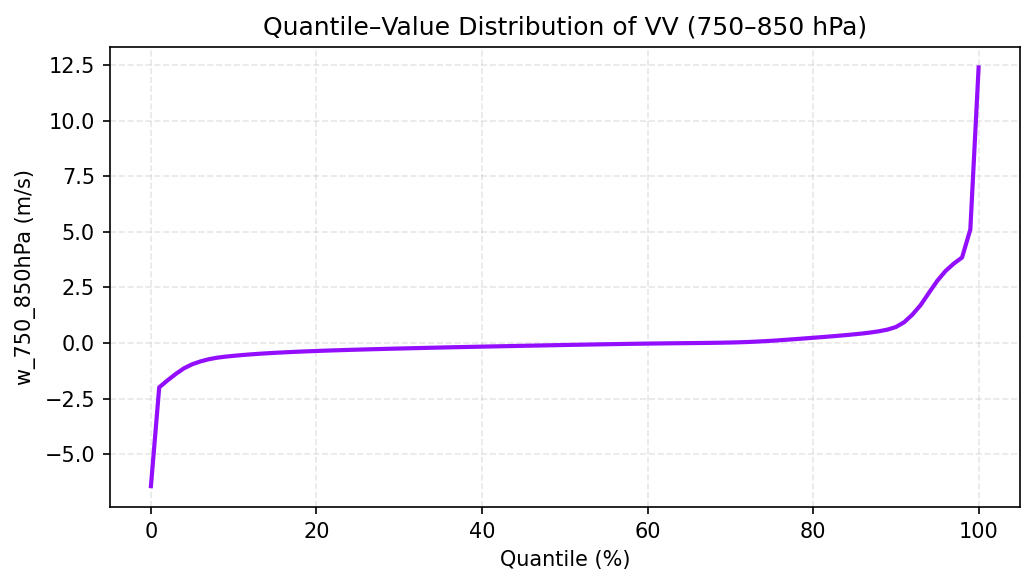

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 取出数据并去除 NaN
data = ds_vvv.w_750_850.values.flatten()
data = data[np.isfinite(data)]

# 计算分位数
q = np.linspace(0, 1, 101)  # 0%, 1%, ..., 100%
values = np.quantile(data, q)

# 绘图
plt.figure(figsize=(7, 4), dpi=150)
plt.plot(q * 100, values, lw=2, color="#920efc")  # 紫色线（与你喜欢的颜色一致）
plt.grid(alpha=0.3, ls="--")
plt.xlabel("Quantile (%)")
plt.ylabel("w_750_850hPa (m/s)")
plt.title("Quantile–Value Distribution of VV (750–850 hPa)")
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd

START = "2016-01-01 00:00:00"
END   = "2023-12-31 23:58:00"

# 先把缺失的10分钟点补成 NaN（保持原10分钟网格）
full_10min = pd.date_range(START, END, freq="10min")
ds_10 = ds_vvv.sortby("time").reindex(time=full_10min)

# 目标 2 分钟时间轴
target_2min = pd.date_range(START, END, freq="2min")

# 按时间线性插值到 2 分钟（边界外不外推 -> 超出范围仍是 NaN）
ds_2min = ds_10.interp(time=target_2min, method="linear")

In [7]:
import numpy as np

arr = ds_vvv.w_750_850.values.flatten()
arr = arr[np.isfinite(arr)]

print(np.nanmin(arr), np.nanmax(arr))
print(np.nanpercentile(arr, [1, 5, 50, 95, 99, 99.9]))

-6.4322605 12.386232
[-1.99211502 -0.95228955 -0.08857307  2.79358499  5.10519642  8.13087331]


In [10]:
ds_2min.to_netcdf('/data/ggong/ARM_monthly/SGP/VV_2min_750_850.nc')

## VV — 600 hPa

In [17]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from datetime import datetime
import re

# ===================== 路径 =====================
base_dir = Path("/data/shared_data/ARM_data/ENA/others/enadlprofwstats4newsC1.c1")
out_dir  = Path("/data/ggong/ARM_monthly/ENA/VV_600")
out_dir.mkdir(parents=True, exist_ok=True)

# ===================== 函数 =====================
def convert_time_to_datetime(ds, date_str):
    """将 time 设为当天 10 分钟分辨率（144 个点）的时间坐标，并移除旧的 units 避免冲突。"""
    times = pd.date_range(start=pd.Timestamp(date_str), periods=144, freq="10min")
    ds = ds.assign_coords(time=("time", times))
    # 清理潜在的 units 冲突
    if "units" in ds.time.attrs:
        ds.time.attrs.pop("units", None)
    if "units" in ds.time.encoding:
        ds.time.encoding.pop("units", None)
    return ds

def convert_height_to_coords(ds, start=0.015, step=0.03, unit="km"):
    """
    将 height 转为几何高度坐标（单位 km）。
    按原有层数 n，从 start 开始，每层 step。
    """
    n = ds.sizes["height"]
    new_height = (start + step * np.arange(n, dtype=float))
    ds = ds.assign_coords(height=("height", new_height))
    ds.height.attrs = {"units": unit, "long_name": "Geometric height"}
    return ds

def compute_w_600(ds):
    """
    若 height 层数==133，则提取 w 的最高层（最顶层，isel(height=-1)）；
    否则返回与 time 维度一致的全 NaN。
    输出只有 time 维度。
    """
    if "w" not in ds:
        raise KeyError("数据集中没有变量 'w'")
    if "height" not in ds.dims or "time" not in ds.dims:
        raise KeyError("数据集缺少必要维度 'height' 或 'time'")

    if ds.sizes.get("height", -1) == 133:
        # 直接取最高层；drop=True 以移除 height 维度，仅保留 time
        da = ds["w"].isel(height=-1, drop=True)
    else:
        # 生成与 time 对齐的 NaN 序列
        da = xr.DataArray(
            np.full(ds.sizes["time"], np.nan, dtype=float),
            coords={"time": ds["time"]},
            dims=("time",),
        )

    da.name = "w_600"
    da.attrs = {
        "units": "m/s",
        "long_name": "Top-level w when height has 133 levels; otherwise NaN",
        "note": "Top level corresponds to isel(height=-1) after converting geometric height coords.",
    }
    return da

# ===================== 批处理 =====================
files = sorted(base_dir.glob("*.nc"))
count = 0

for i, f in enumerate(files, 1):
    ds = None
    try:
        ds = xr.open_dataset(f)

        # 从文件名提取日期（形如 .YYYYMMDD.）
        date_match = re.search(r"\.(\d{8})\.", str(f))
        if not date_match:
            raise ValueError(f"无法提取日期: {f}")
        date_str = date_match.group(1)

        # 转换高度/时间坐标
        ds = convert_height_to_coords(ds)          # 仍按既定 0.015 起、步长 0.03 km
        ds = convert_time_to_datetime(ds, date_str)

        # 计算 w_600
        w_600 = compute_w_600(ds)

        # 输出
        out_path = out_dir / f"VV_600_{date_str}.nc"
        w_600.to_netcdf(out_path)
        count += 1

        # 进度打印
        if i % 300 == 0:
            print(f"[{datetime.now()}] 已完成 {i} 个文件")

    except Exception as e:
        print(f"[ERROR] {f}: {e}")

    finally:
        try:
            if ds is not None:
                ds.close()
        except Exception:
            pass

print(f"✅ 全部完成，共输出 {count} 个文件。")


[2025-11-05 16:14:27.156835] 已完成 300 个文件
[2025-11-05 16:14:33.011509] 已完成 600 个文件
[2025-11-05 16:14:39.362785] 已完成 900 个文件
[2025-11-05 16:14:45.215543] 已完成 1200 个文件
[2025-11-05 16:14:51.299954] 已完成 1500 个文件
[2025-11-05 16:14:57.979126] 已完成 1800 个文件
[2025-11-05 16:15:04.389370] 已完成 2100 个文件
[2025-11-05 16:15:09.906452] 已完成 2400 个文件
✅ 全部完成，共输出 2608 个文件。


In [23]:
ds_vvv=xr.open_mfdataset('/data/ggong/ARM_monthly/ENA/VV_600/*')

In [24]:
import pandas as pd

START = "2016-01-01 00:00:00"
END   = "2023-12-31 23:58:00"

# 先把缺失的10分钟点补成 NaN（保持原10分钟网格）
full_10min = pd.date_range(START, END, freq="10min")
ds_10 = ds_vvv.sortby("time").reindex(time=full_10min)

# 目标 2 分钟时间轴
target_2min = pd.date_range(START, END, freq="2min")

# 按时间线性插值到 2 分钟（边界外不外推 -> 超出范围仍是 NaN）
ds_2min = ds_10.interp(time=target_2min, method="linear")

In [25]:
ds_2min.to_netcdf('/data/ggong/ARM_monthly/ENA/VV_2min_600.nc')

## VV vertical profile

In [44]:
# df_top = pd.read_csv('/data/ggong/ARM_monthly/ENA/csv_file/df_top_with_minutes.csv')
# df_middle = pd.read_csv('/data/ggong/ARM_monthly/ENA/csv_file/df_top_with_minutes.csv')
# df_bottom = pd.read_csv('/data/ggong/ARM_monthly/ENA/csv_file/df_top_with_minutes.csv')

In [43]:
import os, glob
import numpy as np
import pandas as pd
import xarray as xr

def convert_time_to_datetime(ds, date_str):
    times = pd.date_range(start=pd.Timestamp(date_str), periods=144, freq="10min")
    ds = ds.assign_coords(time=("time", times))
    ds.time.attrs.pop("units", None)
    ds.time.encoding.pop("units", None)
    return ds

def convert_height_to_coords(ds, start=0.015, step=0.03, unit="km"):
    n = ds.sizes["height"]
    h = start + step * np.arange(n, dtype=float)
    ds = ds.assign_coords(height=("height", h))
    ds.height.attrs = {"units": unit, "long_name": "Geometric height"}
    return ds

vv_dir   = "/data/shared_data/ARM_data/SGP/others/sgpdlprofwstats4newsC1.c1"
csv_path = "/data/ggong/ARM_monthly/SGP/csv_file/df_middle_with_minutes.csv"
out_path = "/data/ggong/ARM_monthly/SGP/mete_profile/middle/vv_profile.nc"
os.makedirs(os.path.dirname(out_path), exist_ok=True)

df = pd.read_csv(csv_path).copy()
if "minutes" in df.columns and "minute" not in df.columns:
    df = df.rename(columns={"minutes": "minute"})
if "second" not in df.columns:
    df["second"] = 0

df["target_dt"] = pd.to_datetime(df[["year","month","day","hour","minute","second"]])
N = len(df)
time_idx = np.arange(N, dtype=int)
targets = df["target_dt"].to_numpy(dtype="datetime64[ns]")
dates = df["target_dt"].dt.strftime("%Y%m%d").to_numpy()

def find_vv_file(yyyymmdd):
    hits = sorted(glob.glob(os.path.join(vv_dir, f"sgpdlprofwstats4newsC1.c1.{yyyymmdd}.*.custom.nc")))
    return hits[0] if hits else None

w_all = None
height_ref = None
obs_time = np.full(N, np.datetime64("NaT"), dtype="datetime64[ns]")
missing_days = []

# group indices by yyyymmdd
date_to_idx = {}
for i, d in enumerate(dates):
    date_to_idx.setdefault(d, []).append(i)

for yyyymmdd, idx in date_to_idx.items():
    f = find_vv_file(yyyymmdd)
    if f is None:
        missing_days.append(yyyymmdd)
        continue

    date_str = f"{yyyymmdd[:4]}-{yyyymmdd[4:6]}-{yyyymmdd[6:8]}"
    ds = xr.open_dataset(f)
    if "w" not in ds.data_vars or "time" not in ds.dims or "height" not in ds.dims:
        raise ValueError(f"Bad vv file: {f}; dims={ds.dims}; vars={list(ds.data_vars)}")

    ds = convert_time_to_datetime(ds, date_str)
    ds = convert_height_to_coords(ds)

    sel = ds.sel(time=xr.DataArray(targets[idx], dims="time"), method="nearest")  # sel["w"] -> (time, height)

    if height_ref is None:
        height_ref = sel["height"].values
        H = height_ref.size
        w_all = np.full((N, H), np.nan, float)

    obs_time[np.array(idx, int)] = sel["time"].values

    wv = sel["w"].values
    n_t = wv.shape[0]
    h_sel = wv.shape[1]
    H = w_all.shape[1]

    tmp = np.full((n_t, H), np.nan, float)
    m = min(H, h_sel)
    tmp[:, :m] = wv[:, :m]  # 如果只有 67 层，后面自动保持 NaN；如果更多层则截断

    w_all[np.array(idx, int), :] = tmp

ds_out = xr.Dataset(
    data_vars={
        "w": (("time","height"), w_all),
        "obs_time": (("time",), obs_time),
        "target_time": (("time",), targets),
    },
    coords={"time": time_idx, "height": height_ref if height_ref is not None else np.array([])},
)

ds_out.to_netcdf(out_path)
print(f"[done] saved events={N}, height={ds_out.dims.get('height', None)} -> {out_path}")
if missing_days:
    print(f"[warn] missing vv files for {len(missing_days)} days. First 10: {missing_days[:10]}")


[done] saved events=1697, height=133 -> /data/ggong/ARM_monthly/SGP/mete_profile/middle/vv_profile.nc
[warn] missing vv files for 34 days. First 10: ['20161123', '20161209', '20161210', '20161215', '20161218', '20161225', '20170119', '20170120', '20170202', '20170204']
